<a href="https://colab.research.google.com/github/den4hic/practice_python_1/blob/main/python_practice_10_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Оцінювання наявності даної роботи буде враховувати як наявність самих візуалізацій (вони можуть незначно відрізнятися від прикладів, але повинні змістовно відображати суть задачі) та опис отриманих вами результатів. При наявності ЛИШЕ візуалізацій без роз'яснень, завдання не буде зараховане за наявне.

Під час виконання вам дозволено користуватися будь-якими зручними для вас Python бібліотеками для візуалізації.

# I. Receiving Data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. (2б) Для виконання цієї лабораторної роботи Вам необхідно скористатися вибіркою titanic ([train.csv](https://www.kaggle.com/c/titanic/data?select=train.csv)). Зчитайте його та збережіть його у змінну, щоб у подальшому її використати для візуалізацій. Виведіть інформацію про кожну колонку, її індекс, тип та кількість непропущених значень та перші кілька рядків датафрейму.


In [2]:
titanic_df = pd.read_csv('train.csv')

print(titanic_df.info())

print(titanic_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                      

# IІ. Data Visualization.

2. (10б) Створіть pie chart, який би показував співвідношення виживших до загиблих.

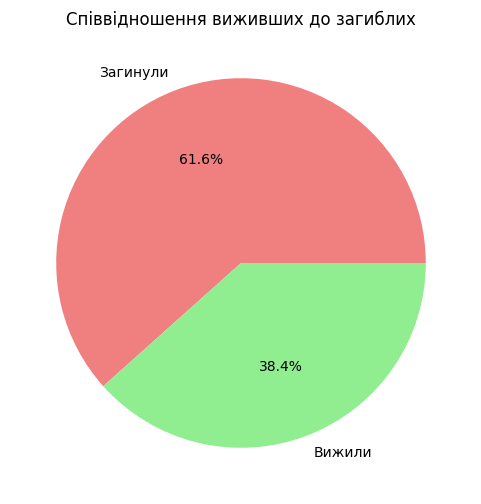

In [3]:
survived_counts = titanic_df['Survived'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(survived_counts, labels=['Загинули', 'Вижили'], autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'])
plt.title('Співвідношення виживших до загиблих')
plt.show()

На графіку видно, що більшість пасажирів (понад 60%) загинули під час катастрофи

3. (20б) Створіть bar chart, який би показував співвідношення загиблих до виживших для кожної статі. Для groupby використовуйте атрибут as_index=False.


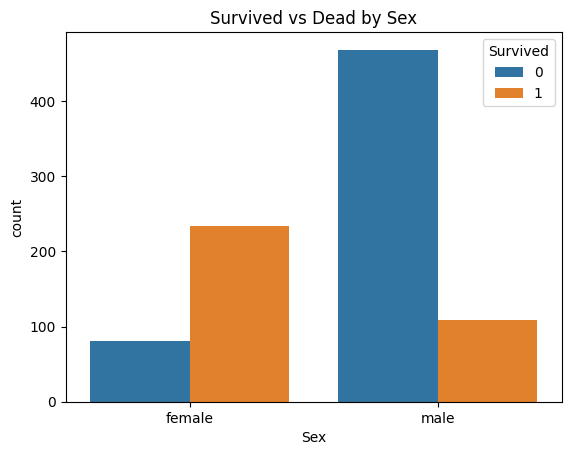

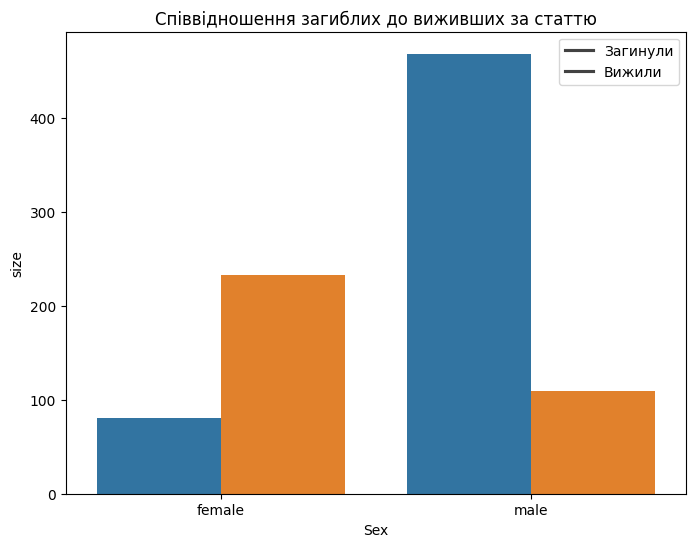

In [4]:
survival_by_gender = titanic_df.groupby(['Sex', 'Survived'], as_index=False).size()

plt.figure(figsize=(8, 6))
sns.barplot(data=survival_by_gender, x='Sex', y='size', hue='Survived')
plt.title('Співвідношення загиблих до виживших за статтю')
plt.legend(labels=['Загинули', 'Вижили'])
plt.show()

Графік демонструє значну різницю: серед жінок відсоток тих, хто вижив, значно вищий, ніж серед чоловіків

4. (20б) Відобразіть кількість пропущених значень в датасеті по кожній із змінних.

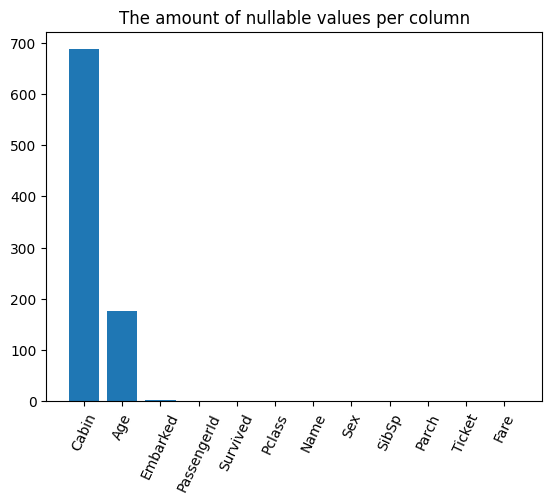

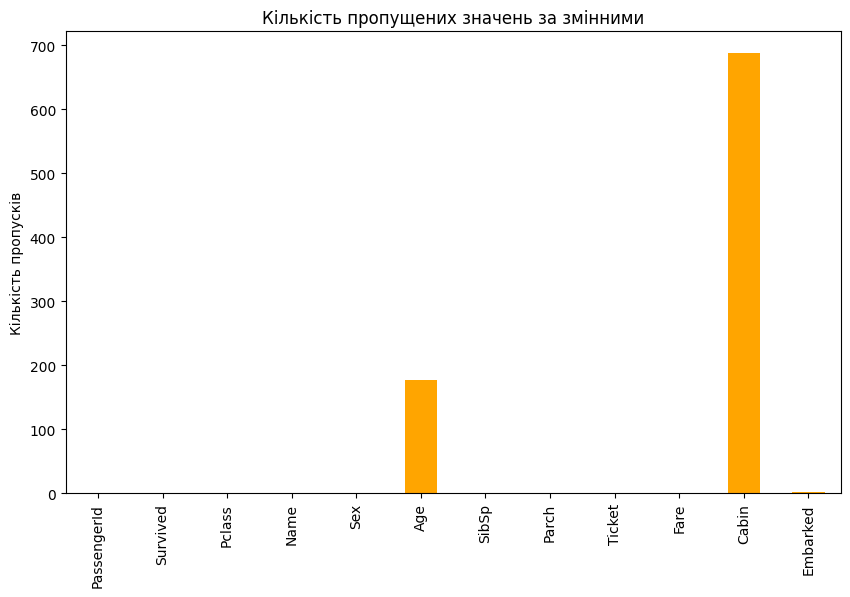

In [6]:
missing_values = titanic_df.isnull().sum()

plt.figure(figsize=(10, 6))
missing_values.plot(kind='bar', color='orange')
plt.title('Кількість пропущених значень за змінними')
plt.ylabel('Кількість пропусків')
plt.show()

Найбільше пропущених значень у колонці Cabin, також є пропуски в Age та майже немає в Embarked

5. (10б) Побудуйте наступний графік, дайте йому назву та опишіть, що власне на них відображається.

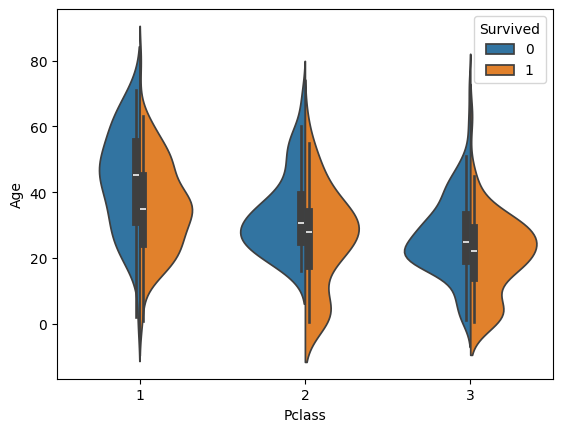

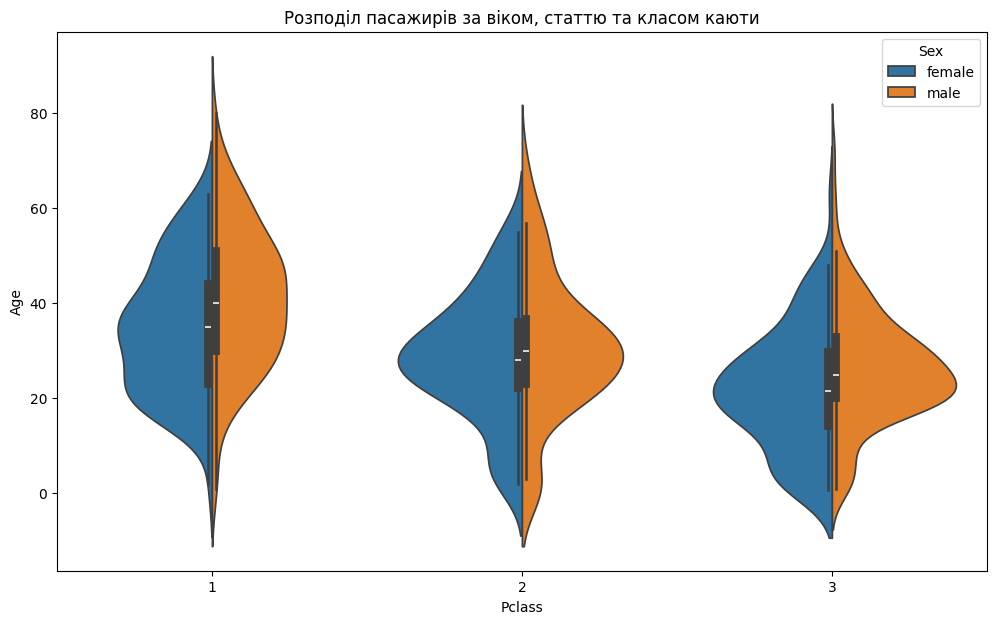

In [7]:
plt.figure(figsize=(12, 7))
sns.violinplot(data=titanic_df, x='Pclass', y='Age', hue='Sex', split=True)
plt.title('Розподіл пасажирів за віком, статтю та класом каюти')
plt.show()

На цьому графіку відображається щільність розподілу віку пасажирів у кожному з трьох класів, розділена за статтю. Можна помітити, що в першому класі пасажири в середньому старші, ніж у третьому.

6. (13б) Побудуйте графік розподілу частот по віку пасажирів.


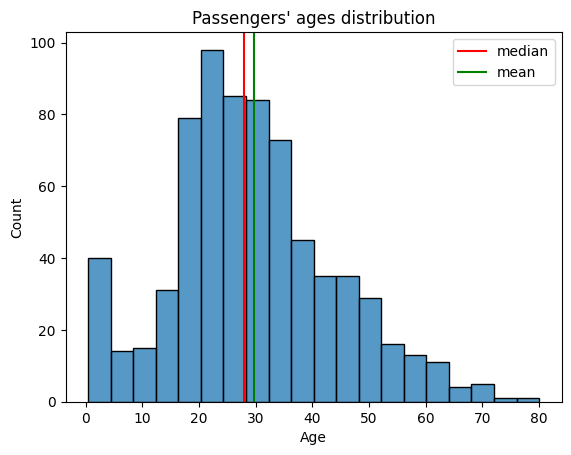

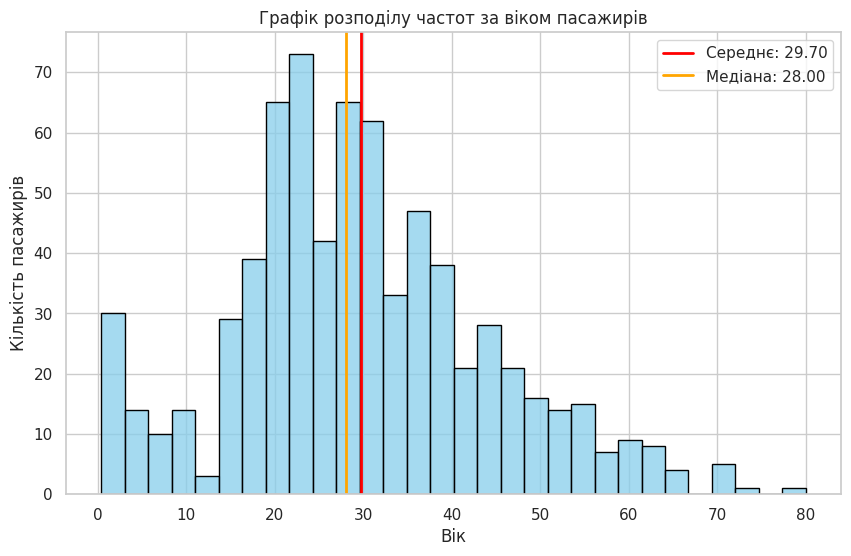

In [12]:
mean_age = titanic_df['Age'].mean()
median_age = titanic_df['Age'].median()

plt.figure(figsize=(10, 6))

sns.histplot(titanic_df['Age'].dropna(), bins=30, color='skyblue', edgecolor='black')

plt.axvline(mean_age, color='red', linestyle='-', linewidth=2, label=f'Середнє: {mean_age:.2f}')

plt.axvline(median_age, color='orange', linestyle='-', linewidth=2, label=f'Медіана: {median_age:.2f}')

plt.title('Графік розподілу частот за віком пасажирів')
plt.xlabel('Вік')
plt.ylabel('Кількість пасажирів')
plt.legend()

plt.show()

найбільша група пасажирів — це молоді люди віком від 20 до 35 років. Також помітний невеликий сплеск у лівій частині графіка, що відповідає дітям (0-5 років)

7. (25б) Поставте бізнес-питання до даних. Дайте на нього відповідь за допомогою візуалізацій. Прокоментуйте отриману відповідь.

Як клас квитка впливав на виживання пасажирів різних вікових груп серед чоловіків та жінок? Чи був пріоритет порятунку 'спочатку жінки та діти' однаковим для всіх класів?

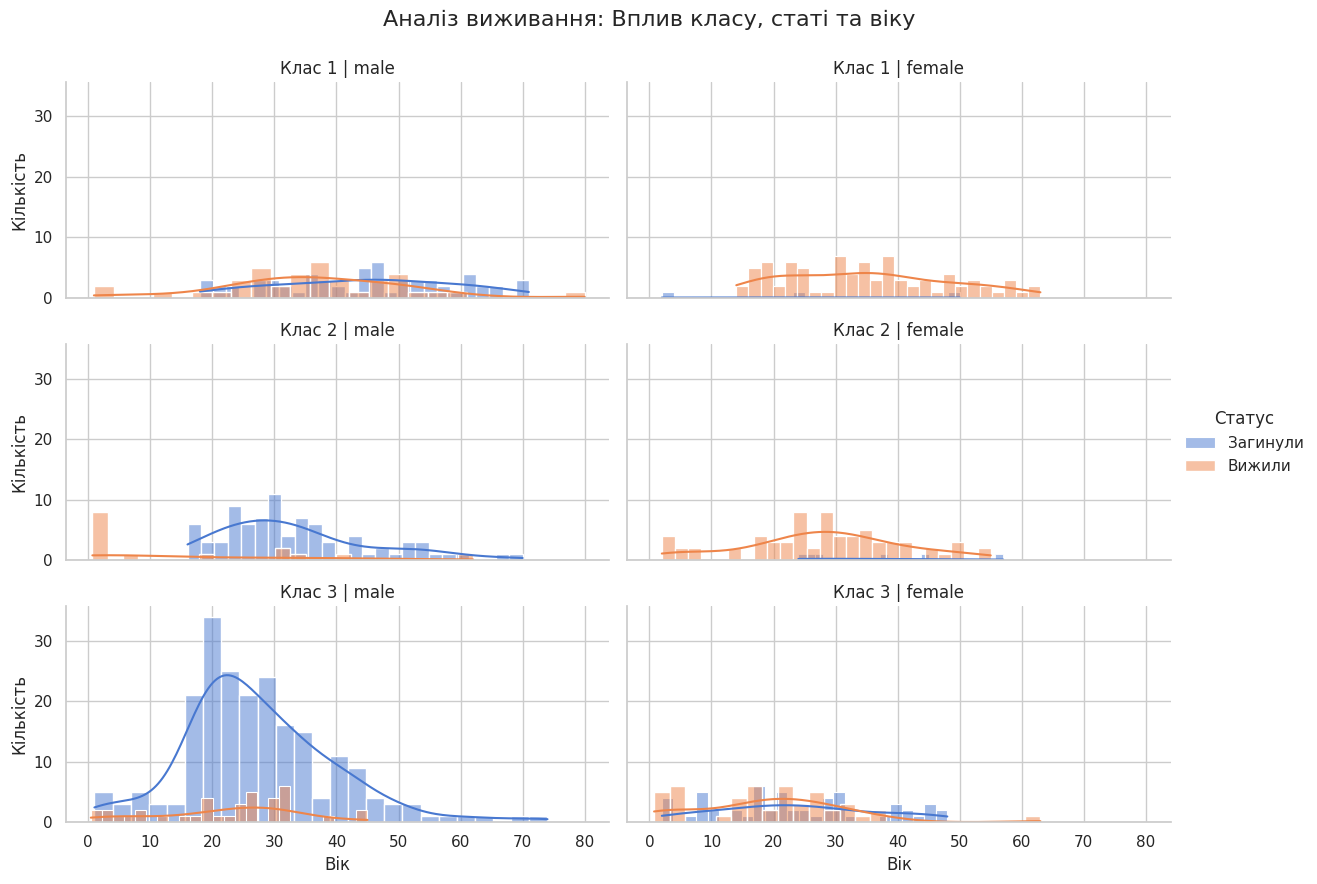

In [13]:
df_plot = titanic_df.copy()
df_plot['Статус'] = df_plot['Survived'].map({0: 'Загинули', 1: 'Вижили'})

g = sns.FacetGrid(df_plot, col="Sex", row="Pclass", hue="Статус",
                  height=3, aspect=2, palette="muted", sharex=True)

g.map(sns.histplot, "Age", bins=25, alpha=0.5, kde=True)

g.add_legend()
g.set_axis_labels("Вік", "Кількість")
g.set_titles(row_template="Клас {row_name}", col_template="{col_name}")

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Аналіз виживання: Вплив класу, статі та віку', fontsize=16)

plt.show()

пасажири першого класу мали значно вищі шанси на порятунок завдяки доступу до човнів та кращому розташуванню кают. Візуалізація підтверджує, що висока вартість квитка та приналежність до привілейованого класу фактично забезпечували безпеку, тоді як пасажири третього класу стикалися з найвищим рівнем смертності незалежно від віку

# Вітаю! Ви велика(ий) молодець, що впоралась(вся). Похваліть себе та побалуйте чимось приємним. Я Вами пишаюся.

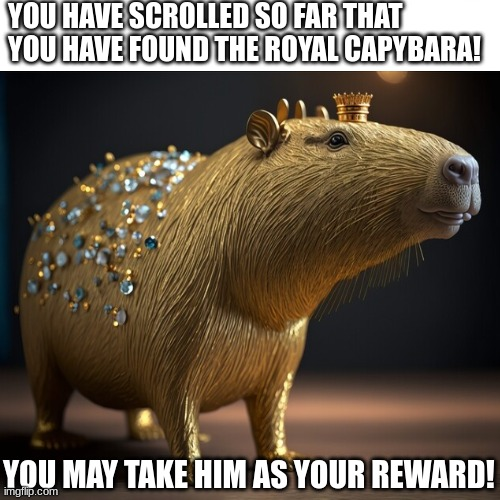